In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('diabetic_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

1. The dataset contains more than 100,000 patient records from diabetic patients.
2. Most columns do not contain missing values.
3. The columns "max_glu_serum" and "A1Cresult" have a very large number of missing values.
4. The dataset contains both numerical and categorical features.
5. The target column 'readmitted' can be used for patient readmission prediction.

In [6]:
missing_per = (df.isnull().sum() / len(df)) * 100
print(missing_per[missing_per > 0])

max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


<Axes: xlabel='readmitted'>

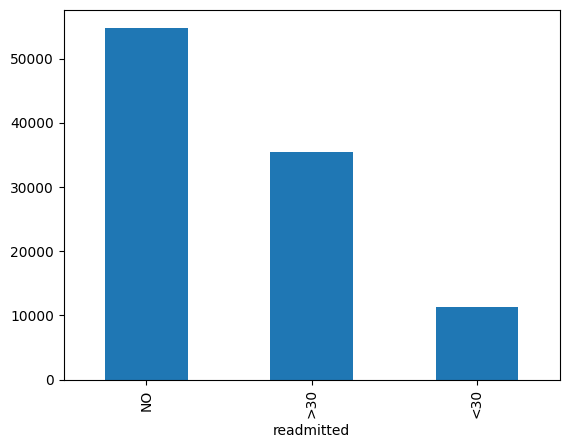

In [7]:
print(df['readmitted'].value_counts())
df['readmitted'].value_counts().plot(kind='bar')

In [8]:
for col in df.columns:
    print(col, df[col].unique()[:5])

encounter_id [2278392  149190   64410  500364   16680]
patient_nbr [ 8222157 55629189 86047875 82442376 42519267]
race ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian']
gender ['Female' 'Male' 'Unknown/Invalid']
age ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)']
weight ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)']
admission_type_id [6 1 2 3 4]
discharge_disposition_id [25  1  3  6  2]
admission_source_id [1 7 2 4 5]
time_in_hospital [1 3 2 4 5]
payer_code ['?' 'MC' 'MD' 'HM' 'UN']
medical_specialty ['Pediatrics-Endocrinology' '?' 'InternalMedicine'
 'Family/GeneralPractice' 'Cardiology']
num_lab_procedures [41 59 11 44 51]
num_procedures [0 5 1 6 2]
num_medications [ 1 18 13 16  8]
number_outpatient [0 2 1 5 7]
number_emergency [0 1 2 4 3]
number_inpatient [0 1 2 3 6]
diag_1 ['250.83' '276' '648' '8' '197']
diag_2 ['?' '250.01' '250' '250.43' '157']
diag_3 ['?' '255' 'V27' '403' '250']
number_diagnoses [1 9 6 7 5]
max_glu_serum [nan '>300' 'Norm' '>200']
A1Cresult [nan '>7' '>8

In [9]:
df=df.replace('?',np.nan)

In [10]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
missing_per = (df.isnull().sum() / len(df)) * 100
print(missing_per[missing_per > 0])

race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
max_glu_serum        94.746772
A1Cresult            83.277322
dtype: float64


In [12]:
df=df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'])

In [13]:
print(df['medical_specialty'].value_counts().head(10))
print(df['payer_code'].value_counts().head(10))

medical_specialty
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Pulmonology                     871
Name: count, dtype: int64
payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
Name: count, dtype: int64


Since it is important for patient admission we can't just drop these columns for now

In [14]:
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['payer_code'] = df['payer_code'].fillna('Unknown')

In [15]:
df.isnull().sum()[df.isnull().sum() > 0]

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64

In [16]:
print(df['race'].dtype)
print(df['diag_1'].dtype)
print(df['diag_2'].dtype)
print(df['diag_3'].dtype)

object
object
object
object


diag 1 2 3 are codes for diagnosis not numerical feautre

In [17]:
df[['race', 'diag_1', 'diag_2', 'diag_3']].isnull().any(axis=1).sum()

np.int64(3713)

In [18]:
(3713 / len(df)) * 100

3.6485663188098183

Since too less rows affected better to drop these

In [19]:
df=df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'])

In [20]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

Since these 2 columns had only 1 uniqe value so will not help in learning

In [21]:
df = df.drop(columns=['examide', 'citoglipton'])

In [22]:
df.shape

(98053, 45)

**EDA**

In [23]:
df['readmitted'].value_counts()

readmitted
NO     52338
>30    34649
<30    11066
Name: count, dtype: int64

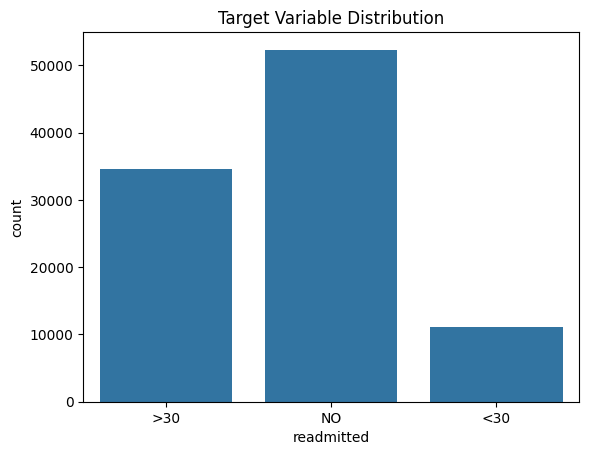

In [24]:
sns.countplot(x='readmitted', data=df)
plt.title('Target Variable Distribution')
plt.show()

In [25]:
df.select_dtypes(include='object').columns

Index(['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1',
       'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [26]:
df.select_dtypes(include='number').columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses'],
      dtype='object')

In [27]:
df = df.drop(columns=['encounter_id', 'patient_nbr'])

In [28]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(cat_cols)
print(num_cols)

['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


There are categories as id not numerical value

In [29]:
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

df[id_cols] = df[id_cols].astype(str)

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 35
Numerical: 8


In [30]:
df.to_csv('diabetic_cleaned.csv', index=False)

In [31]:
for col in df.columns:
    print(col, df[col].unique()[:5])

race ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
gender ['Female' 'Male' 'Unknown/Invalid']
age ['[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)']
admission_type_id ['1' '2' '3' '6' '4']
discharge_disposition_id ['1' '3' '6' '2' '5']
admission_source_id ['7' '2' '4' '1' '5']
time_in_hospital [3 2 1 4 5]
payer_code ['Unknown' 'MC' 'MD' 'HM' 'UN']
medical_specialty ['Unknown' 'InternalMedicine' 'Family/GeneralPractice' 'Cardiology'
 'Surgery-General']
num_lab_procedures [59 11 44 51 31]
num_procedures [0 5 1 6 2]
num_medications [18 13 16  8 21]
number_outpatient [0 2 1 5 7]
number_emergency [0 1 4 2 3]
number_inpatient [0 1 2 3 6]
diag_1 ['276' '648' '8' '197' '414']
diag_2 ['250.01' '250' '250.43' '157' '411']
diag_3 ['255' 'V27' '403' '250' 'V45']
number_diagnoses [9 6 7 5 8]
metformin ['No' 'Steady' 'Up' 'Down']
repaglinide ['No' 'Up' 'Steady' 'Down']
nateglinide ['No' 'Steady' 'Down' 'Up']
chlorpropamide ['No' 'Steady' 'Down' 'Up']
glimepiride ['No' 'Steady' 'Down' '

In [32]:
df = df.drop(columns=['metformin-rosiglitazone'])

In [33]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

In [34]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 34
Numerical: 8


In [35]:
df[num_cols].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000
mean,4.421976,43.148073,1.350749,16.119650,0.376378,0.202462,0.646864,7.512060
std,2.993074,19.712033,1.708506,8.108476,1.283359,0.942892,1.271020,1.832497
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,2.000000,31.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


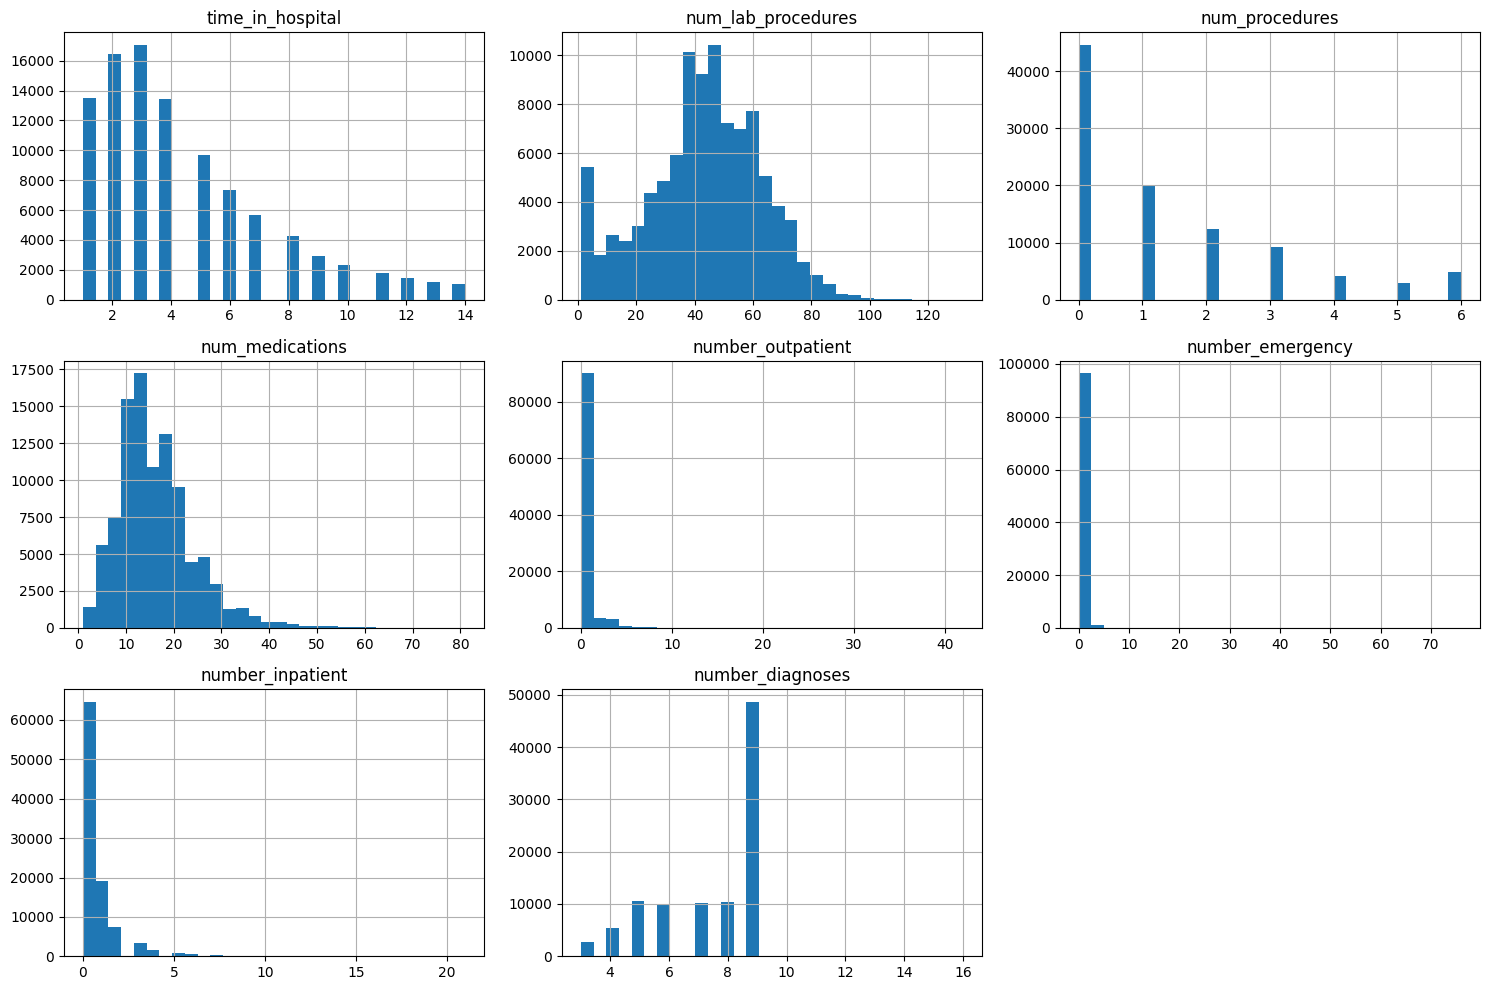

In [36]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [37]:
for col in cat_cols:
    print(col, ':', df[col].nunique(), 'unique values')

race : 5 unique values
gender : 3 unique values
age : 10 unique values
admission_type_id : 8 unique values
discharge_disposition_id : 26 unique values
admission_source_id : 17 unique values
payer_code : 17 unique values
medical_specialty : 73 unique values
diag_1 : 713 unique values
diag_2 : 740 unique values
diag_3 : 786 unique values
metformin : 4 unique values
repaglinide : 4 unique values
nateglinide : 4 unique values
chlorpropamide : 4 unique values
glimepiride : 4 unique values
acetohexamide : 2 unique values
glipizide : 4 unique values
glyburide : 4 unique values
tolbutamide : 2 unique values
pioglitazone : 4 unique values
rosiglitazone : 4 unique values
acarbose : 4 unique values
miglitol : 4 unique values
troglitazone : 2 unique values
tolazamide : 3 unique values
insulin : 4 unique values
glyburide-metformin : 4 unique values
glipizide-metformin : 2 unique values
glimepiride-pioglitazone : 2 unique values
metformin-pioglitazone : 2 unique values
change : 2 unique values
diabe

In [38]:
df['gender'].value_counts()

gender
Female             52833
Male               45219
Unknown/Invalid        1
Name: count, dtype: int64

In [39]:
df = df[df['gender'] != 'Unknown/Invalid']

In [40]:
df.to_csv('diabetic_cleaned.csv', index=False)
print(df.shape)

(98052, 42)
